# Presentación del Proyecto ML (Cumplimiento de Pauta)

Proyecto: Análisis de Defunciones y Nacimientos en Chile — Orquestado con Airflow, Kedro y DVC.

## 1) Contexto y objetivos (1–2 min)
Este proyecto integra datos demográficos de Chile para responder dos preguntas: ¿cómo se comportan las defunciones y nacimientos en el tiempo? y ¿podemos predecir y agrupar patrones relevantes?

Objetivos principales:
- Construir un pipeline reproducible y trazable con **Kedro**.
- Entrenar y promover un modelo supervisado para predicción anual.
- Explorar patrones con análisis **no supervisado** (clustering y reducción dimensional).
- Orquestar todo con **Airflow** y asegurar persistencia con **DVC**.

## 2) Arquitectura y decisiones de diseño (2–3 min)
Usamos una arquitectura de pipelines modular con **Kedro 1.0.0**. **Airflow** coordina tareas: primero corre Kedro, luego dispara en paralelo los algoritmos de clustering y, más tarde, las reducciones dimensionales. Para asegurar auditoría, todo se versiona con **DVC** y se notifica en **Slack**.

Decisiones clave:
- Separar responsabilidades: limpieza, features, modelado y reportes.
- Mantener el flujo supervisado intacto y añadir el no supervisado en paralelo.
- Versionar artefactos críticos (`data/07_model_output` y `models/production`).
- Contenedores con **Docker Compose** para reproducibilidad y credenciales seguras montadas.

## 3) Pipeline de datos y feature engineering (3–4 min)
Los datos crudos se limpian y estandarizan, luego se enriquecen con **features temporales** (mes, día del año, trimestre, ciclos trigonométricos y marcadores de estación). Esto permite que los modelos capturen estacionalidad y tendencias. El dataset de trabajo es `data/03_primary/dataset_con_features_temporales.csv`.


## 4) Modelos supervisados (resultados EP2) (4–5 min)
Entrenamos varios modelos y seleccionamos el mejor. Ese modelo se promociona a producción y se genera una **predicción actual** y un **gráfico** que compara los últimos años con la predicción del año en curso.


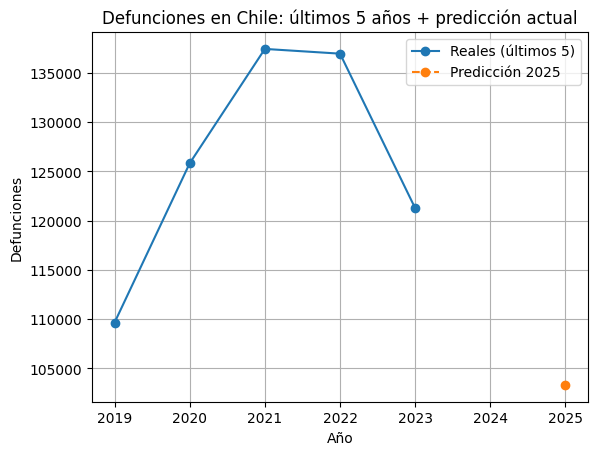

,anio,defunciones_predichas
0,2025,103327


In [29]:
import os, pandas as pd
from IPython.display import Image, display
repo = os.path.abspath(os.path.join(os.getcwd(), '..'))
img_path = os.path.join(repo, 'models/production/fig_prediccion.png')
csv_pred = os.path.join(repo, 'models/production/prediccion_actual.csv')
if os.path.exists(img_path):
    display(Image(filename=img_path))
if os.path.exists(csv_pred):
    display(pd.read_csv(csv_pred).head())

Qué vemos: Comparamos años anteriores con la **predicción del año actual**. Si la predicción sigue la tendencia, el modelo está coherente.

Para qué: Validar que el modelo en producción entrega un resultado claro y útil.

Qué vemos: La imagen compara años anteriores con la **predicción del año actual**. Si la línea prevista sigue la tendencia, el modelo está coherente.

Para qué: Comprobar que el modelo en producción entrega un resultado claro y usable para el negocio.

## 5) Análisis no supervisado (5–7 min)
Probamos **K-Means**, **DBSCAN**, **Jerárquico** y **GMM** para agrupar observaciones sin usar la etiqueta objetivo. K-Means forma grupos por cercanía a centroides, DBSCAN por densidad, Jerárquico construye una estructura de agrupación y GMM usa distribuciones probabilísticas.

Para evaluar la calidad de los grupos, usamos **Silhouette**, **Davies-Bouldin** y **Calinski-Harabasz**. Además, generamos el **Elbow** (K-Means) y el **Dendrograma** (Jerárquico) para entender la estructura y el número adecuado de clusters.

A continuación se muestran métricas y ejemplos visuales generados por el pipeline.

Explicación rápida de visualizaciones:
- **PCA 2D**: Proyección lineal que preserva varianza; útil para visualizar tendencias globales.
- **Biplot de PCA**: Muestra observaciones y flechas de variables (loadings) sobre PC1/PC2 para interpretar qué variables explican la variación.
- **t-SNE 2D/3D**: Preserva estructura local (vecinos); ideal para ver micro-grupos y separaciones sutiles.
- **UMAP 2D**: Preserva estructura local y global; complementa t-SNE y puede mostrar relaciones más continuas.
- **SVD truncado**: Alternativa lineal para datos de alta dimensionalidad; útil como baseline y para sparsidad.
- **Dendrograma**: Estructura jerárquica de agrupamiento; ayuda a elegir nivel de corte y entender fusiones entre grupos.

Interpretación de métricas:
- **Silhouette** alto (≈1) y **Davies-Bouldin** bajo indican separación clara entre clusters.
- **Calinski-Harabasz** más alto favorece clusters bien compactos y separados.
- **Elbow** sugiere el K óptimo cuando la ganancia marginal de inercia se estabiliza.

In [30]:
import os, pandas as pd
def read_csv_robusto(p):
    for enc in ('utf-8', 'latin-1', 'cp1252'):
        try:
            return pd.read_csv(p, encoding=enc)
        except UnicodeDecodeError:
            pass
    return pd.read_csv(p, encoding='latin-1')
base = os.path.abspath(os.path.join(os.getcwd(), '..'))
pca_var = os.path.join(base, 'data/07_model_output/reduction/pca_varianza_explicada.csv')
pca_load = os.path.join(base, 'data/07_model_output/reduction/pca_loadings.csv')
if os.path.exists(pca_var):
    display(read_csv_robusto(pca_var))
if os.path.exists(pca_load):
    display(read_csv_robusto(pca_load).head(20))

,component,explained_variance_ratio
0,pc1,0.604019
1,pc2,0.228664


,feature,pc1,pc2
0,año,-1.012985,-0.232013
1,nacimientos_totales,1.036403,0.053004
2,defunciones_totales,-0.997511,0.093699
3,nacimientos_hombres,1.037330,0.070213
4,nacimientos_mujeres,1.034840,0.035188
5,defunciones_hombres,-0.983216,0.175402
6,defunciones_mujeres,-1.006287,-0.002613
7,tasa_natalidad,1.036405,0.053020
8,tasa_mortalidad,-0.997491,0.093620
9,ratio_nacimientos_sexo,-0.043578,0.760154


Qué vemos: **PC1 ≈ 60%**, **PC2 ≈ 23%** (≈ **83%** acumulado). **PC1** recoge natalidad y crecimiento; **PC2** recoge diferencias por **sexo** en nacimientos/defunciones.

Para qué: Decidir cuántas PCs usar y entender qué variables empujan las primeras componentes.

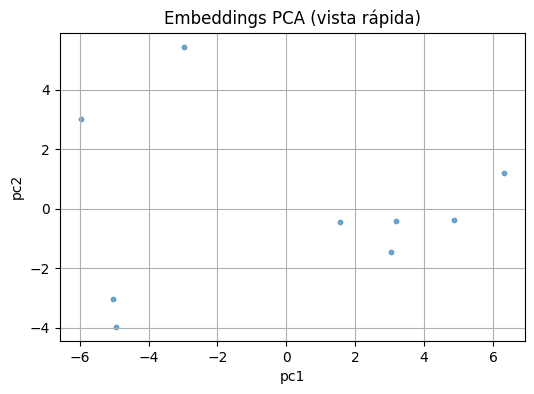

In [31]:
import os, pandas as pd, matplotlib.pyplot as plt
base = os.path.abspath(os.path.join(os.getcwd(), '..'))
pca_path = os.path.join(base, 'data/07_model_output/reduction/embeddings_pca.csv')
if os.path.exists(pca_path):
    df_pca = pd.read_csv(pca_path)
    if df_pca.shape[1] >= 2:
        plt.figure(figsize=(6,4))
        plt.scatter(df_pca.iloc[:,0], df_pca.iloc[:,1], s=10, alpha=0.6)
        plt.title('Embeddings PCA (vista rápida)')
        plt.xlabel(df_pca.columns[0]); plt.ylabel(df_pca.columns[1])
        plt.grid(True)
        plt.show()

Qué vemos: En **PCA 2D** vemos el **mapa general**. Si hay **bandas** o **grupos**, hay patrones globales.

Para qué: Tener una vista rápida y simple de la **estructura global** antes de t-SNE/UMAP.

Qué vemos: En el **biplot** las **flechas** dicen qué variables **empujan** los puntos. Flechas **largas** pesan más; flechas con **mismo sentido** están relacionadas.

Para qué: Entender **qué variables** influyen en PC1/PC2 y **por qué** se forman grupos.

Qué vemos: En **t-SNE 2D** se ven **subgrupos** pequeños. Puntos juntos comparten vecinos; **islas separadas** sugieren clústeres fuertes.

Para qué: Resaltar la **vecindad** que PCA no muestra y detectar subgrupos naturales.

Qué vemos: En **t-SNE 3D** los grupos se separan más que en 2D. Si al rotar hay superposición, las fronteras son difusas.

Para qué: Confirmar la separación añadiendo una dimensión y detectar artefactos.

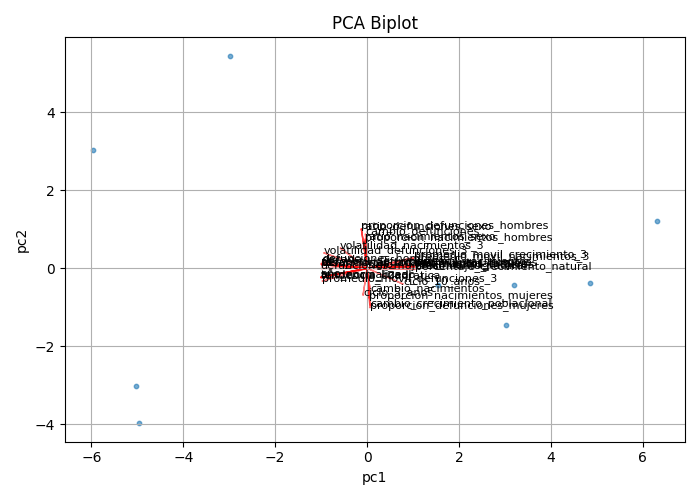

In [32]:
import os
from IPython.display import Image, display
base = os.path.abspath(os.path.join(os.getcwd(), '..'))
biplot = os.path.join(base, 'data/07_model_output/reduction/pca_biplot.png')
if os.path.exists(biplot):
    display(Image(filename=biplot))

Qué vemos: En **UMAP 2D** aparecen **grupos** y a veces **puentes** entre ellos. Puentes = transiciones; islas compactas = clústeres claros.

Para qué: Ver relaciones **continuas** y jerárquicas como complemento de t-SNE.

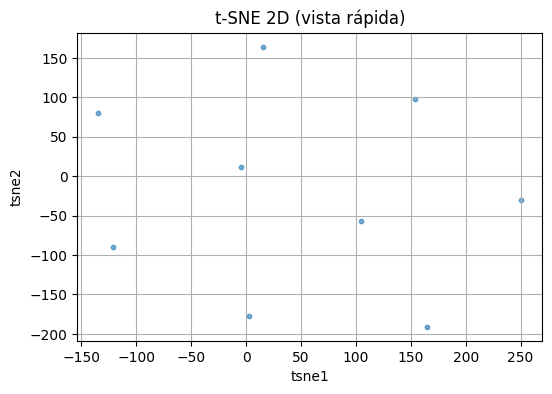

In [33]:
import os, pandas as pd, matplotlib.pyplot as plt
base = os.path.abspath(os.path.join(os.getcwd(), '..'))
tsne2d = os.path.join(base, 'data/07_model_output/reduction/embeddings_tsne.csv')
if os.path.exists(tsne2d):
    df = pd.read_csv(tsne2d)
    if df.shape[1] >= 2:
        plt.figure(figsize=(6,4))
        plt.scatter(df.iloc[:,0], df.iloc[:,1], s=10, alpha=0.6)
        plt.title('t-SNE 2D (vista rápida)')
        plt.xlabel(df.columns[0]); plt.ylabel(df.columns[1])
        plt.grid(True)
        plt.show()

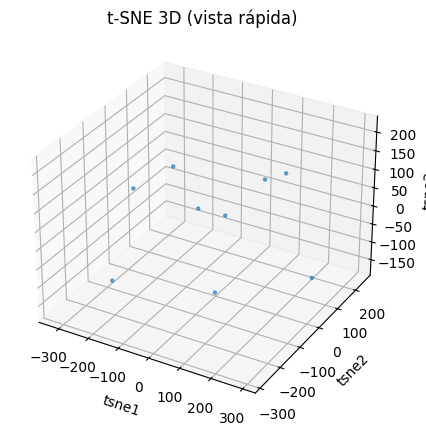

In [34]:
import os, pandas as pd, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
base = os.path.abspath(os.path.join(os.getcwd(), '..'))
tsne3d = os.path.join(base, 'data/07_model_output/reduction/embeddings_tsne3d.csv')
if os.path.exists(tsne3d):
    df = pd.read_csv(tsne3d)
    if df.shape[1] >= 3:
        fig = plt.figure(figsize=(7,5))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(df.iloc[:,0], df.iloc[:,1], df.iloc[:,2], s=5, alpha=0.6)
        ax.set_title('t-SNE 3D (vista rápida)')
        ax.set_xlabel(df.columns[0]); ax.set_ylabel(df.columns[1]); ax.set_zlabel(df.columns[2])
        plt.show()

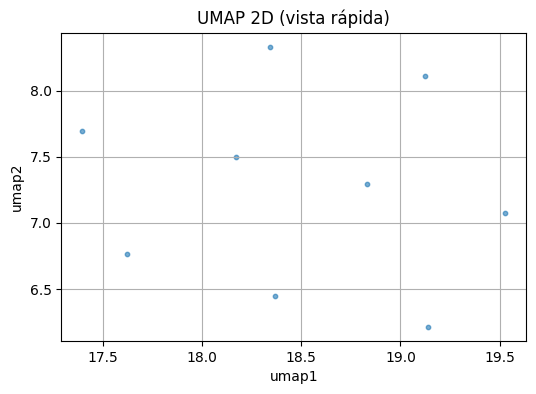

In [35]:
import os, pandas as pd, matplotlib.pyplot as plt
base = os.path.abspath(os.path.join(os.getcwd(), '..'))
umap = os.path.join(base, 'data/07_model_output/reduction/embeddings_umap.csv')
if os.path.exists(umap):
    df = pd.read_csv(umap)
    if df.shape[1] >= 2:
        plt.figure(figsize=(6,4))
        plt.scatter(df.iloc[:,0], df.iloc[:,1], s=10, alpha=0.6)
        plt.title('UMAP 2D (vista rápida)')
        plt.xlabel(df.columns[0]); plt.ylabel(df.columns[1])
        plt.grid(True)
        plt.show()

In [36]:
import os, pandas as pd
base = os.path.abspath(os.path.join(os.getcwd(), '..'))
met_res = os.path.join(base, 'data/07_model_output/metricas_resumen.csv')
met_mod = os.path.join(base, 'data/07_model_output/metricas_modelos.csv')
elbow = os.path.join(base, 'data/07_model_output/clustering/elbow_kmeans.csv')
if os.path.exists(met_res):
    display(pd.read_csv(met_res).head())
if os.path.exists(met_mod):
    display(pd.read_csv(met_mod).head())
if os.path.exists(elbow):
    display(pd.read_csv(elbow).head())

,index,modelo,RMSE,MAE,R2
0,0,gbr,2.064458e+04,1.614027e+04,-1.452616
1,1,lasso,3.046209e+02,2.143540e+02,0.999466
2,2,linreg,1.823745e-09,1.469743e-09,1.000000
3,3,rf,2.265675e+04,1.834952e+04,-1.954014
4,4,ridge,2.141315e-03,1.587756e-03,1.000000


,modelo,RMSE,MAE,R2
0,gbr,2.064458e+04,1.614027e+04,-1.452616
1,lasso,3.046209e+02,2.143540e+02,0.999466
2,linreg,1.823745e-09,1.469743e-09,1.000000
3,rf,2.265675e+04,1.834952e+04,-1.954014
4,ridge,2.141315e-03,1.587756e-03,1.000000


,n_clusters,wcss
0,3,112.190977
1,4,51.330066
2,5,32.508347
3,6,20.277546
4,7,8.728486


In [37]:
import os, pandas as pd, matplotlib.pyplot as plt
base = os.path.abspath(os.path.join(os.getcwd(), '..'))
pca_path = os.path.join(base, 'data/07_model_output/reduction/embeddings_pca.csv')
if False and os.path.exists(pca_path):
    df_pca = pd.read_csv(pca_path)
    if df_pca.shape[1] >= 2:
        plt.figure(figsize=(6,4))
        plt.scatter(df_pca.iloc[:,0], df_pca.iloc[:,1], s=10, alpha=0.6)
        plt.title('Embeddings PCA (vista rápida)')
        plt.xlabel(df_pca.columns[0]); plt.ylabel(df_pca.columns[1])
        plt.grid(True)
        plt.show()

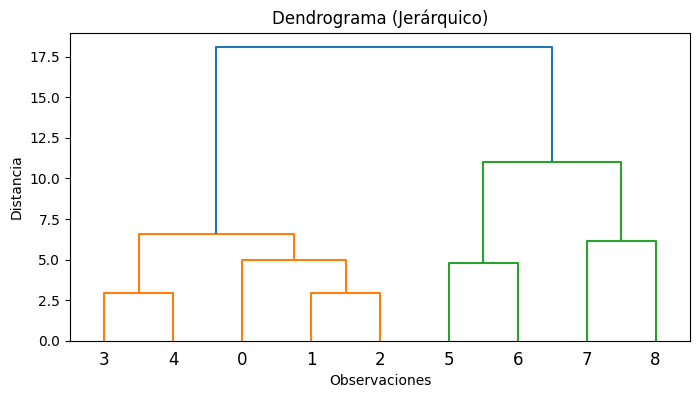

In [38]:
import os, pickle
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
base = os.path.abspath(os.path.join(os.getcwd(), '..'))
dendro_pkl = os.path.join(base, 'data/07_model_output/clustering/dendrogram_hier.pkl')
if os.path.exists(dendro_pkl):
    with open(dendro_pkl, 'rb') as f:
        obj = pickle.load(f)
    Z = obj.get('linkage')
    if Z is not None:
        plt.figure(figsize=(8,4))
        dendrogram(Z)
        plt.title('Dendrograma (Jerárquico)')
        plt.xlabel('Observaciones'); plt.ylabel('Distancia')
        plt.show()

Qué vemos: El **dendrograma** es un **árbol** de uniones. **Cortes bajos** = grupos compactos; **ramas largas** = grupos muy separados.

Para qué: Elegir el **nivel de corte** para decidir cuántos grupos usar.

### ¿Qué significa?
Si los **clusters** están bien separados, las métricas serán mejores (Silhouette alto, Davies-Bouldin bajo). El **Elbow** ayuda a elegir cuántos grupos usar en K-Means. El **Dendrograma** muestra cómo se forman los grupos paso a paso. Los **embeddings** (PCA/t-SNE/UMAP) reducen dimensiones para ver la estructura.

## 6) Integración, orquestación y despliegue (2–3 min)
El DAG `ml_modelado_kedro_dvc` ejecuta el pipeline de Kedro, promueve el modelo y genera visualizaciones. En paralelo, corre el análisis no supervisado y luego versiona todas las salidas con DVC. Si todo sale bien, se notifica por Slack. Esto deja el proyecto listo para operar y auditar.

## 7) Desafíos y soluciones (1–2 min)
- Encadenamiento de dependencias en Airflow: se corrigió el error al usar listas encadenadas y se aplicó un bucle para definir las dependencias.
- Entornos y librerías: se agregó `umap-learn` y se consolidaron versiones en Docker para evitar incompatibilidades.
- Versionado confiable: los secretos de DVC se montan en el contenedor y se agrega `dvc add` a directorios y archivos clave.
- Predicción robusta: se implementó manejo de valores faltantes antes de predecir y graficar.

## 8) Conclusiones y trabajo futuro (1–2 min)
Se cumple la pauta: se comparan **≥3 algoritmos de clustering** con **métricas** y **visualizaciones**; el flujo está **orquestado** y **versionado**. Próximos pasos: incorporar **OPTICS**, explorar **anomalías** y crear un tablero interactivo con las principales métricas y embeddings.

Criterios de defensa:
- **Dominio técnico**: Explicar por qué cada algoritmo y métrica fue elegido, interpretar PCA/t-SNE/UMAP y decisiones de parámetros.
- **Comunicación**: Relatar objetivos, arquitectura y resultados con terminología clara y apoyarse en visualizaciones.
- **Demo práctica**: Ejecutar en vivo `scripts/run_unsupervised.py --step all`, navegar nodos de Kedro y mostrar artefactos.
- **Trabajo en equipo**: Alternar explicaciones entre ambos, coordinar el relato y complementar respuestas.